In [19]:
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"
 
df = pl.read_parquet(DATA_PATH)
print(df.shape)
 
TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id", 'is_raining', 'is_snowing', 'is_fog']
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
    'temperature_c', 'precipitation_mm', 'snowfall_cm', 'windspeed_kmh', 'weathercode',
    'segment_length',
    'scheduled_segment_speed_mps',
]

FEATURES = CATEGORICAL + NUMERIC

(57341, 31)


In [21]:
groups = df["trip_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups))
 
train_df = df[train_idx]
test_df = df[test_idx]

 
print(f"train: {train_df.shape} | test: {test_df.shape}")
print(f"train trips: {train_df['trip_id'].n_unique():,} | "
      f"test trips: {test_df['trip_id'].n_unique():,} | "
      f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

train: (45480, 31) | test: (11861, 31)
train trips: 1,005 | test trips: 252 | overlap: 0


In [22]:
for c in FEATURES:
    print(c, train_df.schema[c])

route_id String
direction_id Int64
shape_id String
service_id String
is_raining Int8
is_snowing Int8
is_fog Int8
stop_sequence UInt32
trip_progress Float64
hour Int8
weekday Int8
month Int8
is_peak Int8
scheduled_arrival Int32
scheduled_departure Int32
scheduled_segment_time Int32
stop_lat Float64
stop_lon Float64
latitude Float32
longitude Float32
bearing Float32
temperature_c Float64
precipitation_mm Float64
snowfall_cm Float64
windspeed_kmh Float64
weathercode Int64
segment_length Float64
scheduled_segment_speed_mps Float64


In [23]:
import pandas as pd
 
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:

    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series(s.to_list(), dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)
 
X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

In [24]:
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
 
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3022
[LightGBM] [Info] Number of data points in the train set: 45480, number of used features: 25
[LightGBM] [Info] Start training from score 92.806266
Training until validation scores don't improve for 50 rounds


c:\Users\ishan\anaconda3\envs\DL\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's l1: 32.4707
[200]	valid_0's l1: 31.6511
[300]	valid_0's l1: 31.3734
[400]	valid_0's l1: 31.2298
[500]	valid_0's l1: 31.1622
[600]	valid_0's l1: 31.117
[700]	valid_0's l1: 31.0879
[800]	valid_0's l1: 31.0362
[900]	valid_0's l1: 31.0154
Early stopping, best iteration is:
[916]	valid_0's l1: 31.0052


,num_leaves,63
,learning_rate,0.03
,n_estimators,2000
,objective,'regression'
,min_child_samples,30
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,metric,'mae'
,boosting_type,'gbdt'
,max_depth,-1


In [25]:
preds = model.predict(X_test, num_iteration=model.best_iteration_)
 
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
 
print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
 
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")

MAE:  31.0 sec
RMSE: 55.5 sec
R2:   0.4878

Naive baseline (scheduled_segment_time only) MAE: 46.4 sec
Improvement over naive: 33.2%


In [26]:
importance = (
    pl.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": model.feature_importances_,
    })
    .sort("importance", descending=True)
)
print(importance)
 
# %%
# ---------------------------------------------------
# Save
# ---------------------------------------------------
 
model.booster_.save_model("models/lgbm_weather_and_segments.txt")
print("model saved")

shape: (28, 2)
┌────────────────────────┬────────────┐
│ feature                ┆ importance │
│ ---                    ┆ ---        │
│ str                    ┆ i32        │
╞════════════════════════╪════════════╡
│ scheduled_arrival      ┆ 7082       │
│ scheduled_segment_time ┆ 5459       │
│ segment_length         ┆ 4994       │
│ bearing                ┆ 4920       │
│ longitude              ┆ 4496       │
│ …                      ┆ …          │
│ weekday                ┆ 26         │
│ month                  ┆ 6          │
│ is_snowing             ┆ 0          │
│ is_fog                 ┆ 0          │
│ snowfall_cm            ┆ 0          │
└────────────────────────┴────────────┘
model saved


                        Feature  Importance
13            scheduled_arrival        7082
15       scheduled_segment_time        5459
26               segment_length        4994
20                      bearing        4920
19                    longitude        4496
18                     latitude        4297
8                 trip_progress        3291
16                     stop_lat        3040
27  scheduled_segment_speed_mps        3010
17                     stop_lon        2999
7                 stop_sequence        2378
2                      shape_id        2364
24                windspeed_kmh        2247
21                temperature_c        2014
14          scheduled_departure        1497
9                          hour         929
25                  weathercode         728
12                      is_peak         335
3                    service_id         225
22             precipitation_mm         162
0                      route_id         118
1                  direction_id 

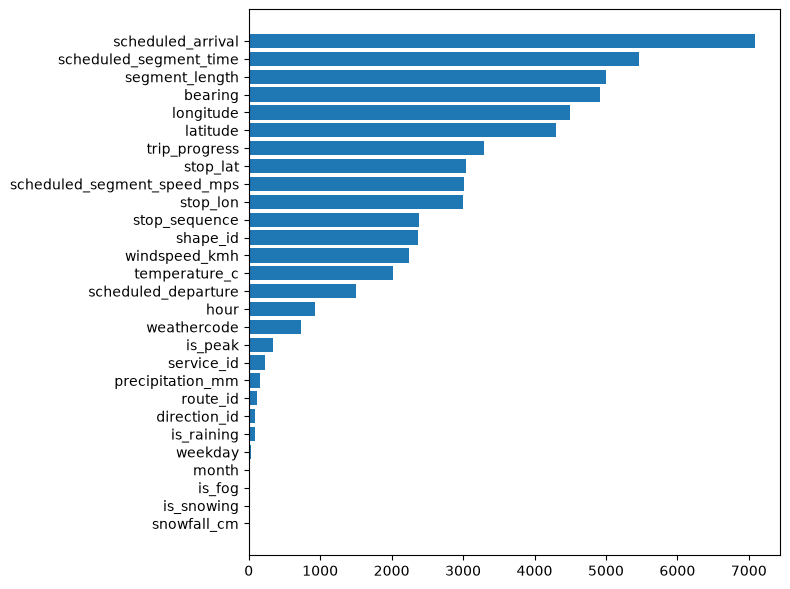

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(fi)

plt.figure(figsize=(8,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()